In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

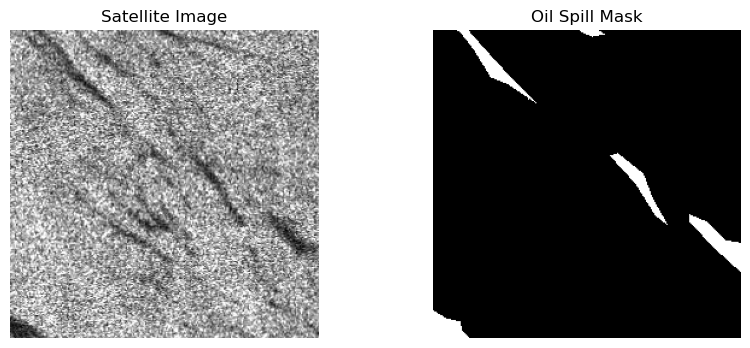

In [19]:
#Visualizing sample satellite images & masks for EDA
#Loading and displaying one image–mask pair

IMAGE_DIR = "oil_spill_dataset/train/images"
MASK_DIR = "oil_spill_dataset/train/masks"

image_files = sorted(os.listdir(IMAGE_DIR))

sample_image = image_files[0]

img = cv2.imread(os.path.join(IMAGE_DIR, sample_image), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(MASK_DIR, sample_image), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Oil Spill Mask")
plt.axis("off")

plt.show()


In [21]:
#studying statistical properties (Spill vs Non-Spill)
#analyzing pixel intensities

spill_pixels = img[mask > 0]
non_spill_pixels = img[mask == 0]

print("Spill region mean intensity:", np.mean(spill_pixels))
print("Non-spill region mean intensity:", np.mean(non_spill_pixels))

Spill region mean intensity: 89.8393485915493
Non-spill region mean intensity: 157.56725784016186


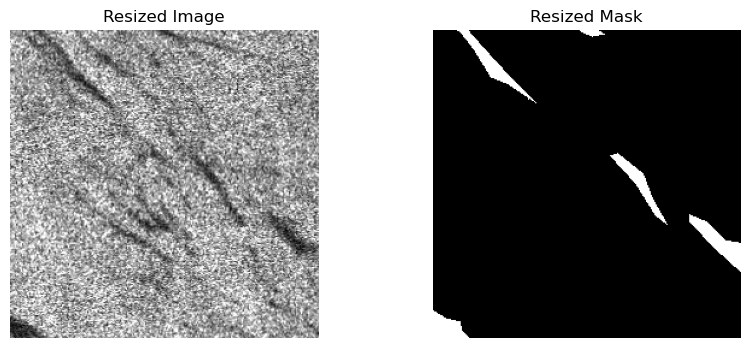

In [22]:
#resizing images to 256x256 as U Net requires fixed input size
def resize_image(image, size=(256,256)):
    return cv2.resize(image, size, interpolation=cv2.INTER_NEAREST)

img_resized = resize_image(img)
mask_resized = resize_image(mask)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_resized, cmap='gray')
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_resized, cmap='gray')
plt.title("Resized Mask")
plt.axis("off")
plt.show()

In [23]:
#Normalizing pixel values as CNNs do not work well on raw pixel range (0-255)

img_normalized = img_resized / 255.0
mask_normalized = mask_resized / 255.0

print("Image min/max:", img_normalized.min(), img_normalized.max())
print("Mask unique values:", np.unique(mask_normalized))

Image min/max: 0.0 1.0
Mask unique values: [0. 1.]


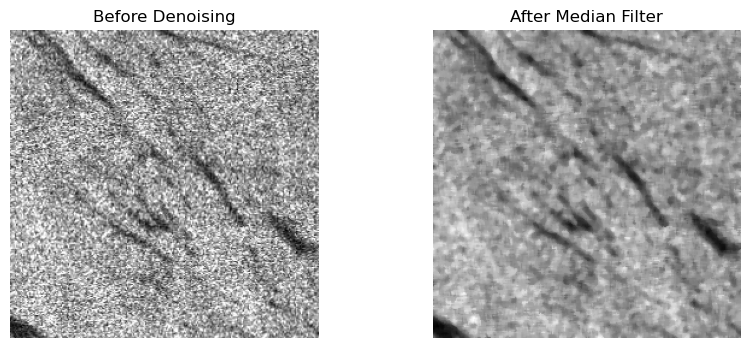

In [24]:
#applying SAR specific speckle noise reduction
#using median filtering

denoised_img = cv2.medianBlur((img_normalized*255).astype(np.uint8), 5)
denoised_img = denoised_img / 255.0

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_normalized, cmap='gray')
plt.title("Before Denoising")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised_img, cmap='gray')
plt.title("After Median Filter")
plt.axis("off")
plt.show()

In [25]:
#Data Augmentation (for generalization)

In [26]:
#Horizontal Flip
flipped_img = np.fliplr(denoised_img)
flipped_mask = np.fliplr(mask_normalized)

In [27]:
#Rotation
rotated_img = np.rot90(denoised_img)
rotated_mask = np.rot90(mask_normalized)

In [28]:
#brightness variation
bright_img = np.clip(denoised_img * 1.2, 0, 1)

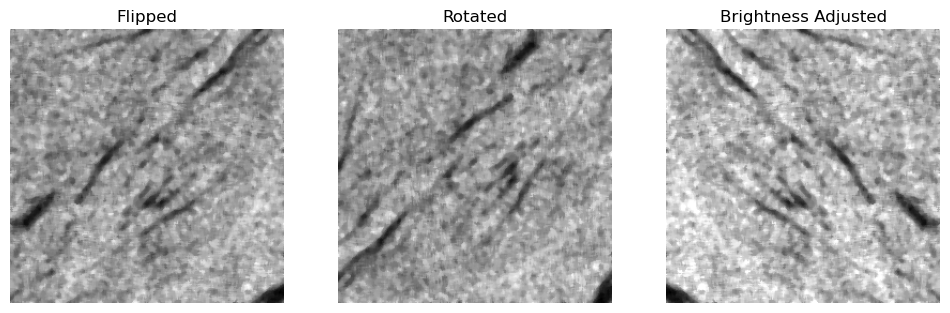

In [29]:
#visualization
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(flipped_img, cmap='gray')
plt.title("Flipped")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bright_img, cmap='gray')
plt.title("Brightness Adjusted")
plt.axis("off")

plt.show()